# Project Overview and Fraud Analysis Guide

This notebook is the main navigation page for the BNPL merchant-selection project. It explains where each project component is stored, shows the main committed visual outputs, and documents how the fraud analysis feeds the final ranking.

**Audience:** project team members, tutors and reviewers who need one place to understand the repository.

**Important:** this notebook reads committed summary files and figures. It does not require raw consumer or transaction tables, and it does not expose private API keys or raw data.

## Contents

1. [Repository roadmap](#1.-Repository-roadmap)
2. [Existing project visuals](#2.-Existing-project-visuals)
3. [Fraud analysis location and run order](#3.-Fraud-analysis-location-and-run-order)
4. [Fraud outputs](#4.-Fraud-outputs)
5. [Merchant model validation](#5.-Merchant-model-validation)
6. [Fraud score distribution and reliability](#6.-Fraud-score-distribution-and-reliability)
7. [Fraud-weight sensitivity](#7.-Fraud-weight-sensitivity)
8. [How fraud enters the final ranking](#8.-How-fraud-enters-the-final-ranking)
9. [Output finder](#9.-Output-finder)
10. [Recommended execution order](#10.-Recommended-execution-order)

## 1. Repository roadmap

The repository follows this dependency order:

| Stage | Main location | Main purpose | Key downstream output |
|---|---|---|---|
| Member 1 | [`member1_eda/`](member1_eda/) | Explore the supplied tables and document quality, coverage and distributions | EDA figures and summary CSV files |
| Member 2 | [`member2_curation/`](member2_curation/) | Clean and join the core internal tables | `curated_transactions` and audit reports |
| External data | [`external_census/`](external_census/), [`external_seifa/`](external_seifa/), [`external_ato/`](external_ato/), [`external_integration/`](external_integration/) | Clean postcode-level external data and validate matching | Integrated postcode feature table |
| Member 3 features | [`member3_merchant_features/`](member3_merchant_features/) | Aggregate transaction behaviour and external regional features to one row per merchant | `merchant_features.parquet` |
| Member 3 growth | [`member3_industry_growth/`](member3_industry_growth/) | Analyse revenue growth for five industry groups | Growth summaries and charts |
| Member 4 | [`member4_fraud/`](member4_fraud/) | Model consumer and merchant fraud-risk signals and combine them | `knn_fraud_risk_scores.csv` |
| Member 5 | [`member5_ranking/`](member5_ranking/) | Combine business value and fraud safety into the final shortlist | Overall Top 100 and five Segment Top 10 lists |

The code cell below checks that the important entry points and outputs exist in the current checkout.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "member4_fraud").exists() and (candidate / "member5_ranking").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")

ROOT = find_repo_root(Path.cwd())
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "font.size": 11,
})

checkpoints = {
    "Member 1 notebook": ROOT / "member1_eda" / "member1_eda.ipynb",
    "Member 2 curation notebook": ROOT / "member2_curation" / "curation_summary" / "curation_summary.ipynb",
    "Member 3 merchant features": ROOT / "member3_merchant_features" / "results" / "merchant_features.parquet",
    "Member 3 industry growth": ROOT / "member3_industry_growth" / "results" / "industry_growth_summary.csv",
    "Member 4 fraud README": ROOT / "member4_fraud" / "README.md",
    "Member 4 KNN risk scores": ROOT / "member4_fraud" / "result" / "knn_fraud_risk_scores.csv",
    "Member 5 final Top 100": ROOT / "member5_ranking" / "results" / "final_top_100.csv",
    "Member 5 segment Top 10": ROOT / "member5_ranking" / "results" / "segment_top_10.csv",
}

repository_check = pd.DataFrame({
    "item": checkpoints.keys(),
    "relative_path": [str(path.relative_to(ROOT)) for path in checkpoints.values()],
    "present": [path.exists() for path in checkpoints.values()],
})
display(repository_check)
assert repository_check["present"].all(), "One or more expected repository outputs are missing."
print(f"Repository root: {ROOT}")

,item,relative_path,present
0,Member 1 notebook,member1_eda\member1_eda.ipynb,True
1,Member 2 curation notebook,member2_curation\curation_summary\curation_summary.ipynb,True
2,Member 3 merchant features,member3_merchant_features\results\merchant_features.parquet,True
3,Member 3 industry growth,member3_industry_growth\results\industry_growth_summary.csv,True
4,Member 4 fraud README,member4_fraud\README.md,True
5,Member 4 KNN risk scores,member4_fraud\result\knn_fraud_risk_scores.csv,True
6,Member 5 final Top 100,member5_ranking\results\final_top_100.csv,True
7,Member 5 segment Top 10,member5_ranking\results\segment_top_10.csv,True


Repository root: .


## 2. Existing project visuals

The following figures connect the main stages of the project:

- Member 1 establishes the transaction-value distribution and highlights the long right tail.
- Member 3 tracks industry-group revenue using full calendar months for the comparable trend window.
- Member 5 shows how the final Top 100 is distributed across the five agreed industry groups.

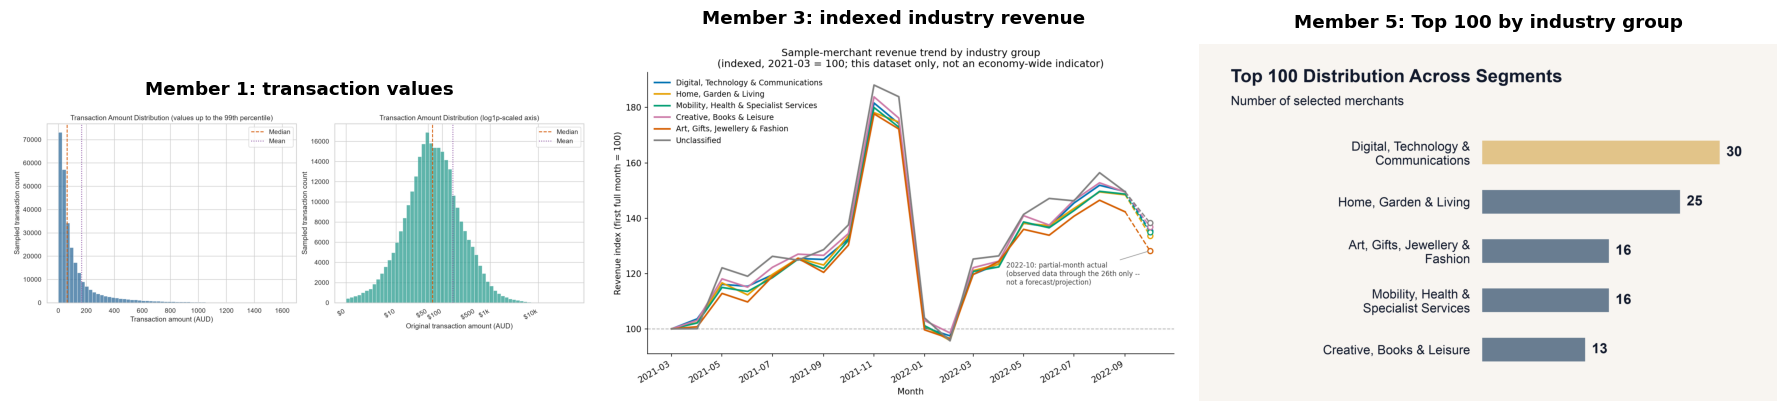

In [2]:
figure_specs = [
    (
        ROOT / "member1_eda" / "member1_eda_outputs" / "figures" / "01_transaction_amount_distribution.png",
        "Member 1: transaction values",
    ),
    (
        ROOT / "member3_industry_growth" / "results" / "charts" / "industry_growth_indexed.png",
        "Member 3: indexed industry revenue",
    ),
    (
        ROOT / "member5_ranking" / "results" / "presentation_top100_segment_distribution.png",
        "Member 5: Top 100 by industry group",
    ),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (image_path, title) in zip(axes, figure_specs):
    if image_path.exists():
        ax.imshow(plt.imread(image_path))
        ax.set_title(title, pad=12)
    else:
        ax.text(0.5, 0.5, f"Missing:\n{image_path.name}", ha="center", va="center")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Plot discussion

**Transaction values:** the original-scale distribution is strongly right-skewed. The log-scale panel makes the central mass visible without deleting large transactions. Extreme values remain available for audit and sensitivity checks.

**Industry growth:** the comparison uses the full-month window from March 2021 to September 2022. October 2022 is only partially observed and should not be interpreted as a complete-month business decline.

**Top 100 composition:** the chart describes the industry composition of the final shortlist. The five Segment Top 10 lists are views within the same selected pool, rather than 50 additional onboarding recommendations.

## 3. Fraud analysis location and run order

Fraud work is contained in [`member4_fraud/`](member4_fraud/). Start with its [`README.md`](member4_fraud/README.md).

Run the three notebooks in this order:

1. [`consumer_fraud_analysis.ipynb`](member4_fraud/code/consumer_fraud_analysis.ipynb)  
   Audits the supplied consumer risk labels, creates time-aware behavioural features, compares regression models and produces consumer risk predictions.

2. [`merchant_fraud_analysis.ipynb`](member4_fraud/code/merchant_fraud_analysis.ipynb)  
   Builds the 61-merchant labelled sample, tunes the KNN regression pipeline, runs repeated/nested validation and predicts merchant risk for all eligible merchants.

3. [`fraud_risk_profile.ipynb`](member4_fraud/code/fraud_risk_profile.ipynb)  
   Combines merchant KNN risk with consumer fraud exposure, calculates reliability diagnostics and creates the fraud-risk files used by Member 5.

Supporting Python modules are in [`member4_fraud/code/`](member4_fraud/code/):

- `build_feature_tables.py`: prepares consumer and merchant feature tables.
- `train_consumer_models.py`: trains and evaluates consumer models.
- `build_merchant_model_table.py`: constructs merchant training and scoring tables.
- `train_merchant_models.py`: tunes KNN and comparison models.
- `build_fraud_risk_profile.py`: creates the combined merchant risk profile.

### Fraud inputs

| Input | Location | Role |
|---|---|---|
| Consumer fraud labels | private raw table `consumer_fraud_probability.csv` | Continuous consumer-date risk target |
| Merchant fraud labels | private raw table `merchant_fraud_probability.csv` | Direct observations for 61 merchants |
| Curated transactions | `member2_curation/data/curated/curated_transactions/` | Behavioural history and merchant-consumer links |
| Merchant features | `member3_merchant_features/results/merchant_features.parquet` | Merchant scale, growth, stability and context |

Raw fraud tables and the full transaction partitions remain outside GitHub. The committed result files below support review without exposing those raw inputs.

## 4. Fraud outputs

All retained fraud deliverables are stored in [`member4_fraud/result/`](member4_fraud/result/).

| Output | Grain | What it contains | Used by |
|---|---|---|---|
| `consumer_fraud_predictions_all.csv` | Consumer | Consumer risk at the scoring date | Merchant consumer-exposure calculation |
| `merchant_fraud_predictions_all.csv` | Merchant | Cross-validated KNN predictions and label availability | Risk-profile builder |
| `merchant_fraud_risk_profile.csv` | Merchant | Detailed KNN, consumer exposure, coverage and direct-label evidence | Audit and reporting |
| `knn_fraud_risk_scores.csv` | Merchant | Compact risk, confidence, OOD flag and 70/30, 50/50, 30/70 scenarios | Member 5 ranking |
| `merchant_model_comparison.csv` | Model | Repeated-CV and held-out test metrics | Model selection evidence |
| `merchant_nested_cv_summary.csv` | Validation summary | Nested-CV estimate of the tuning procedure | Robustness evidence |
| `merchant_loocv_summary.csv` | Validation summary | Leave-one-out sensitivity results | Small-sample check |
| `fraud_risk_coverage_summary.csv` | Metric | Evidence coverage and OOD counts | Limitations and reporting |
| `fraud_weight_sensitivity_summary.csv` | Scenario | Rank and Top-100 stability across three component weights | Sensitivity analysis |

The next cell loads the key review files and prints the evidence-coverage summary.

In [3]:
FRAUD_RESULTS = ROOT / "member4_fraud" / "result"

merchant_models = pd.read_csv(FRAUD_RESULTS / "merchant_model_comparison.csv")
nested_cv = pd.read_csv(FRAUD_RESULTS / "merchant_nested_cv_summary.csv")
loocv = pd.read_csv(FRAUD_RESULTS / "merchant_loocv_summary.csv")
split_summary = pd.read_csv(FRAUD_RESULTS / "merchant_data_split_summary.csv")
coverage = pd.read_csv(FRAUD_RESULTS / "fraud_risk_coverage_summary.csv")
risk_scores = pd.read_csv(FRAUD_RESULTS / "knn_fraud_risk_scores.csv")
weight_sensitivity = pd.read_csv(FRAUD_RESULTS / "fraud_weight_sensitivity_summary.csv")

coverage_view = coverage.assign(value=pd.to_numeric(coverage["value"], errors="coerce"))
display(split_summary)
display(coverage_view)

metrics = dict(zip(coverage_view["metric"], coverage_view["value"]))
labelled = int(metrics["merchants_with_direct_fraud"])
total = int(metrics["total_merchants"])
ood_count = int(metrics["knn_out_of_distribution"])
print(f"Directly labelled merchants: {labelled:,} of {total:,}")
print(f"Merchants outside the labelled sample's 95th-percentile distance threshold: {ood_count:,} ({ood_count / total:.1%})")

,split,merchants,mean_target,min_target,max_target
0,train_for_cv,48,0.457239,0.182109,0.910961
1,held_out_test,13,0.462507,0.277933,0.941347


,metric,value
0,total_merchants,4422.000000
1,merchants_with_consumer_risk,4414.000000
2,merchants_with_direct_fraud,61.000000
3,merchants_with_knn_risk,4422.000000
4,consumer_and_knn,4414.000000
5,consumer_only,0.000000
6,knn_only,8.000000
7,no_information,0.000000
8,knn_out_of_distribution,1763.000000
9,median_knn_confidence,0.098361


Directly labelled merchants: 61 of 4,422
Merchants outside the labelled sample's 95th-percentile distance threshold: 1,763 (39.9%)


## 5. Merchant model validation

The merchant task has only 61 directly labelled merchants. The main selection criterion is Spearman rank correlation because the downstream application ranks merchants rather than treating the score as a calibrated probability.

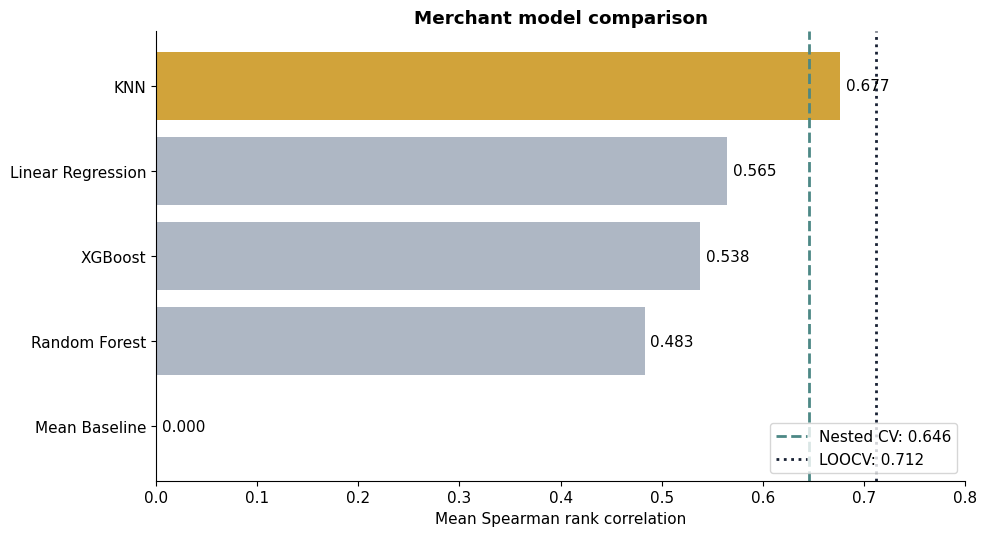

,value
model,KNN
best_parameters,"{""n_features"": 8, ""n_neighbors"": 8, ""p"": 1, ""transformer"": ""power"", ""weights"": ""distan..."
cv_mae_mean,0.092457
cv_rmse_mean,0.137639
cv_r2_mean,0.275539
cv_spearman_mean,0.676652
test_mae,0.114028
test_rmse,0.18648
test_r2,0.299711
test_spearman,0.423077


In [4]:
model_plot = merchant_models.sort_values("cv_spearman_mean", ascending=True).copy()
selected = model_plot["selected_by_cv"].astype(str).str.lower().eq("true")
colors = np.where(selected, "#D1A33A", "#AEB7C4")

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(model_plot["model"], model_plot["cv_spearman_mean"], color=colors)
ax.axvline(float(nested_cv.loc[0, "spearman_mean"]), color="#4C8885", linestyle="--", linewidth=2,
           label=f"Nested CV: {nested_cv.loc[0, 'spearman_mean']:.3f}")
ax.axvline(float(loocv.loc[0, "spearman"]), color="#172033", linestyle=":", linewidth=2,
           label=f"LOOCV: {loocv.loc[0, 'spearman']:.3f}")
ax.set_xlim(0, 0.8)
ax.set_xlabel("Mean Spearman rank correlation")
ax.set_title("Merchant model comparison")
ax.legend(loc="lower right")
ax.bar_label(bars, fmt="%.3f", padding=4)
plt.tight_layout()
plt.show()

selected_row = merchant_models.loc[merchant_models["selected_by_cv"].astype(str).str.lower().eq("true")].iloc[0]
display(selected_row[[
    "model", "best_parameters", "cv_mae_mean", "cv_rmse_mean", "cv_r2_mean",
    "cv_spearman_mean", "test_mae", "test_rmse", "test_r2", "test_spearman"
]].to_frame("value"))

### Discussion

KNN achieved the highest repeated-CV Spearman value, approximately **0.677**, and was selected for merchant scoring. Nested CV produced a Spearman mean of approximately **0.646**, while LOOCV produced approximately **0.712**. The independent 13-merchant holdout Spearman was lower, approximately **0.423**.

These results support KNN as the chosen ranking model, but they do not establish stable probability prediction. The small labelled sample and variation across validation procedures remain important limitations.

## 6. Fraud score distribution and reliability

The final fraud input combines two percentile signals:

- `consumer_exposure_percentile`: amount-weighted exposure to predicted consumer risk.
- `knn_merchant_risk_percentile`: merchant behavioural risk estimated by KNN.

The default `fraud_risk_index` uses the neutral 50/50 combination. `risk_safety_score` reverses that index onto a 0–100 safety scale for the final ranking.

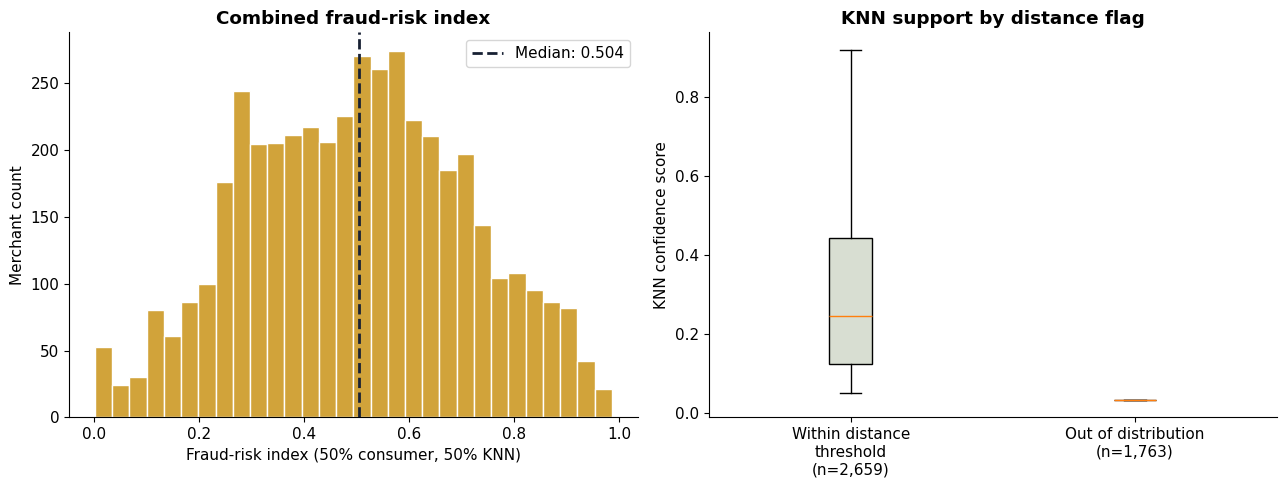

In [5]:
ood = risk_scores["knn_out_of_distribution"].astype(str).str.lower().eq("true")
in_distribution = risk_scores.loc[~ood, "knn_confidence_score"].dropna()
out_distribution = risk_scores.loc[ood, "knn_confidence_score"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(risk_scores["fraud_risk_index"].dropna(), bins=30, color="#D1A33A", edgecolor="white")
axes[0].axvline(risk_scores["fraud_risk_index"].median(), color="#172033", linestyle="--", linewidth=2,
                label=f"Median: {risk_scores['fraud_risk_index'].median():.3f}")
axes[0].set_title("Combined fraud-risk index")
axes[0].set_xlabel("Fraud-risk index (50% consumer, 50% KNN)")
axes[0].set_ylabel("Merchant count")
axes[0].legend()

boxes = axes[1].boxplot(
    [in_distribution, out_distribution],
    tick_labels=[f"Within distance\nthreshold\n(n={len(in_distribution):,})", f"Out of distribution\n(n={len(out_distribution):,})"],
    patch_artist=True,
    showfliers=False,
)
boxes["boxes"][0].set_facecolor("#D8DED2")
boxes["boxes"][1].set_facecolor("#EAD7A8")
axes[1].set_title("KNN support by distance flag")
axes[1].set_ylabel("KNN confidence score")

plt.tight_layout()
plt.show()

### Discussion

Every one of the 4,422 merchants receives a KNN score, but only 61 merchants have direct merchant-fraud observations. **1,763 merchants, about 39.9% of the scored pool, are outside the labelled sample's 95th-percentile neighbour-distance threshold.**

`knn_confidence_score` measures relative similarity to the labelled sample. It is not prediction accuracy or a statistical confidence probability. OOD merchants should receive additional review rather than an automatic penalty or rejection.

## 7. Fraud-weight sensitivity

Member 4 provides three consumer/KNN combinations so the team can see whether the risk ranking depends strongly on one component.

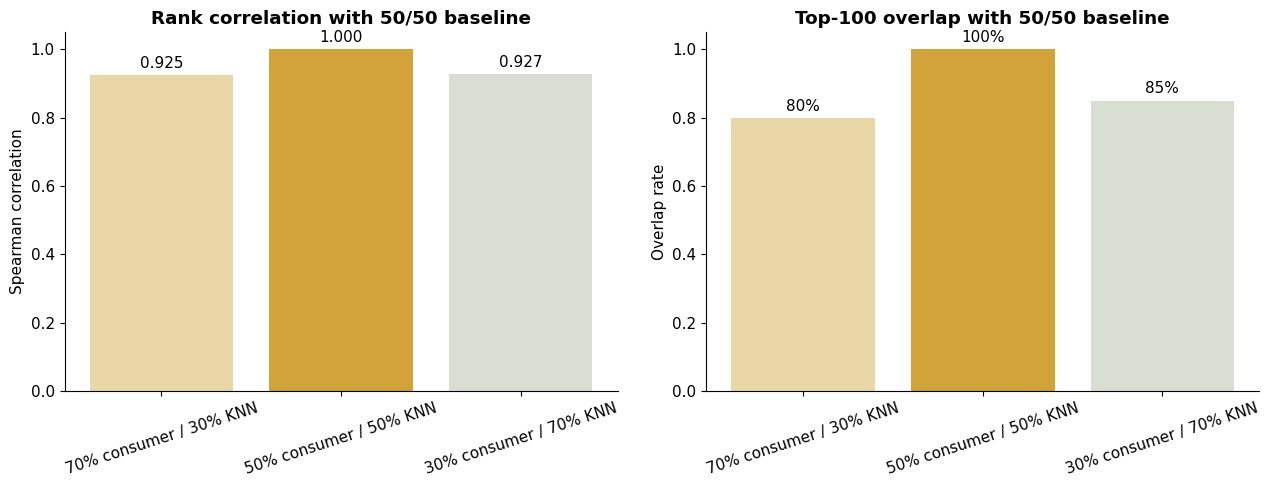

In [6]:
sensitivity = weight_sensitivity.copy()
sensitivity["scenario_label"] = sensitivity["scenario"].map({
    "70c_30knn": "70% consumer / 30% KNN",
    "50c_50knn": "50% consumer / 50% KNN",
    "30c_70knn": "30% consumer / 70% KNN",
}).fillna(sensitivity["scenario"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#EAD7A8", "#D1A33A", "#D8DED2"]

bars1 = axes[0].bar(sensitivity["scenario_label"], sensitivity["spearman_vs_50c_50knn"], color=colors)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Rank correlation with 50/50 baseline")
axes[0].set_ylabel("Spearman correlation")
axes[0].tick_params(axis="x", rotation=18)
axes[0].bar_label(bars1, fmt="%.3f", padding=3)

bars2 = axes[1].bar(sensitivity["scenario_label"], sensitivity["top_100_overlap_rate_vs_50c_50knn"], color=colors)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Top-100 overlap with 50/50 baseline")
axes[1].set_ylabel("Overlap rate")
axes[1].tick_params(axis="x", rotation=18)
axes[1].bar_label(
    bars2,
    labels=[f"{value:.0%}" for value in sensitivity["top_100_overlap_rate_vs_50c_50knn"]],
    padding=3,
)

plt.tight_layout()
plt.show()

### Discussion

Both alternative component-weight scenarios remain highly correlated with the 50/50 baseline. However, the Top-100 overlap falls to **80%** under 70% consumer / 30% KNN and **85%** under 30% consumer / 70% KNN.

The sensitivity results show that the component weights affect which merchants appear at the top of the risk ranking. The neutral 50/50 scenario remains the baseline, while the alternatives document uncertainty rather than identify an objectively optimal weight.

## 8. How fraud enters the final ranking

The downstream path is:

```text
Member 3 merchant features
            +
Member 4 knn_fraud_risk_scores.csv
            +
Member 3 category_to_group_mapping.csv
            ↓
Member 5 ranking_summary.ipynb
            ↓
ranking_analysis_base.csv
            ↓
Member 5 final_recommendations.ipynb
            ↓
final_top_100.csv and segment_top_10.csv
```

Member 5 calculates:

- `BusinessScore = 0.30 Value + 0.25 Customer Reach + 0.20 Growth + 0.15 Stability + 0.10 Market Context`
- `FinalScore = 0.90 BusinessScore + 0.10 FraudSafety`

`FraudSafety` is the 0–100 `risk_safety_score` supplied by Member 4. It is a relative ranking input, not a probability that a merchant is free from fraud.

In [7]:
RANKING_RESULTS = ROOT / "member5_ranking" / "results"
final_top_100 = pd.read_csv(RANKING_RESULTS / "final_top_100.csv")
segment_top_10 = pd.read_csv(RANKING_RESULTS / "segment_top_10.csv")

final_columns = [
    "final_rank", "merchant_abn", "merchant_name", "final_score",
    "balanced_score", "risk_safety_score", "knn_confidence_score",
    "knn_out_of_distribution", "industry_group"
]
final_columns = [column for column in final_columns if column in final_top_100.columns]

print(f"Overall shortlist rows: {len(final_top_100):,}")
print(f"Segment list rows: {len(segment_top_10):,}")
display(final_top_100[final_columns].head(10))

Overall shortlist rows: 100
Segment list rows: 50


,final_rank,merchant_abn,merchant_name,final_score,balanced_score,risk_safety_score,knn_confidence_score,knn_out_of_distribution
0,1,38090089066,Interdum Feugiat Sed Inc.,85.084485,86.800764,69.637978,0.918033,False
1,2,90568944804,Diam Eu Dolor LLC,84.834617,87.168863,63.826405,0.327869,False
2,3,84703983173,Amet Consulting,84.630599,85.765124,74.419880,0.459016,False
3,4,86578477987,Leo In Consulting,84.539430,85.650047,74.543876,0.639344,False
4,5,27326652377,Tellus Aenean Corporation,84.364009,86.253316,67.360254,0.245902,False
5,6,40515428545,Elit Sed Consequat Associates,84.276448,84.659810,80.826198,0.557377,False
6,7,17488304283,Posuere Cubilia Curae Corporation,84.273831,85.080227,77.016270,0.377049,False
7,8,49212265466,Auctor Company,84.246497,85.552242,72.494798,0.885246,False
8,9,86772484982,Posuere Cubilia Curae LLC,84.237758,85.785250,70.310332,0.065574,False
9,10,96680767841,Ornare Limited,84.216013,85.723766,70.646239,0.967213,False


## 9. Output finder

Use this cell when you need to locate a result without manually opening every folder.

In [8]:
output_folders = {
    "Member 1 EDA": ROOT / "member1_eda" / "member1_eda_outputs",
    "Member 2 curation": ROOT / "member2_curation" / "data" / "curated",
    "Member 3 merchant features": ROOT / "member3_merchant_features" / "results",
    "Member 3 industry growth": ROOT / "member3_industry_growth" / "results",
    "Member 4 fraud": ROOT / "member4_fraud" / "result",
    "Member 5 ranking": ROOT / "member5_ranking" / "results",
}

records = []
for section, folder in output_folders.items():
    if not folder.exists():
        records.append({"section": section, "file": "<folder missing>", "type": "", "size_kb": np.nan})
        continue
    for file_path in sorted(folder.rglob("*")):
        if file_path.is_file() and file_path.suffix.lower() in {".csv", ".json", ".png", ".svg", ".parquet"}:
            records.append({
                "section": section,
                "file": str(file_path.relative_to(ROOT)),
                "type": file_path.suffix.lower().lstrip("."),
                "size_kb": round(file_path.stat().st_size / 1024, 1),
            })

output_index = pd.DataFrame(records)
display(output_index)
print(f"Indexed {len(output_index):,} committed output files.")

,section,file,type,size_kb
0,Member 1 EDA,member1_eda\member1_eda_outputs\consumer_gender_counts.csv,csv,0.1
1,Member 1 EDA,member1_eda\member1_eda_outputs\consumer_state_counts.csv,csv,0.1
2,Member 1 EDA,member1_eda\member1_eda_outputs\daily_transaction_trend.csv,csv,60.2
3,Member 1 EDA,member1_eda\member1_eda_outputs\duplicate_key_summary.csv,csv,0.3
4,Member 1 EDA,member1_eda\member1_eda_outputs\figures\01_transaction_amount_distribution.png,png,125.9
...,...,...,...,...
88,Member 5 ranking,member5_ranking\results\top100_score_gap.csv,csv,0.5
89,Member 5 ranking,member5_ranking\results\top100_segment_revenue_contribution.csv,csv,0.6
90,Member 5 ranking,member5_ranking\results\value_only_baseline_comparison.csv,csv,3.0
91,Member 5 ranking,member5_ranking\results\value_only_baseline_membership.csv,csv,21.5


Indexed 93 committed output files.


## 10. Recommended execution order

For a complete rebuild, follow this order:

1. Run Member 1 EDA for descriptive checks.
2. Run the Member 2 curation pipeline to create `curated_transactions`.
3. Build Census, SEIFA and ATO outputs, then run `external_integration`.
4. Run `member3_merchant_features/build_merchant_features.py`.
5. Run `member3_industry_growth/build_industry_growth.py`.
6. Run the three Member 4 fraud notebooks in the order listed above.
7. Restart the kernel and run all cells in `member5_ranking/ranking_summary.ipynb`.
8. Restart the kernel and run all cells in `member5_ranking/final_recommendations.ipynb`.
9. Use `member5_ranking/presentation_analysis.ipynb` for presentation-ready diagnostics.

### Final interpretation reminders

- Supplied fraud values are risk scores, not confirmed fraud events.
- The merchant KNN model has only 61 directly labelled merchants.
- Fraud risk, KNN confidence and final ranking scores are relative decision-support measures.
- The final Top 100 is an onboarding shortlist for further due diligence, not an automatic approval list.
- Raw data and credentials should remain outside GitHub.